# Data Ingestion & Requirement Filtering Pipeline Test Notebook

This notebook tests the data ingestion pipeline, transforming raw uploaded documents (`pdf`, `docx`, `txt`) into a clean set of requirements (`dict[str, str]`).
It utilizes the documents under `test_project/ingestion_docs_test` as test inputs:
- `KaggleReq.pdf`
- `OfficerDispatcher.txt`
- `System_Requirements_Template.docx`

In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path
from IPython.display import JSON, Markdown, display

# Setup project root path
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "ingestion").exists() and (REPO_ROOT.parent / "ingestion").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from ingestion.graph import build_ingestion_graph
from ingestion.schema import IngestionConfig, FilterConfig, IngestionContext
from ingestion.validation import validate_ingestion_config, validate_filter_config
from ingestion.exceptions import (
    EmptyFileError,
    UnsupportedFormatError,
    ExtractionError,
    EmptyRequirementsError,
    FormatMismatchError
)

display(Markdown(f"**Workspace project root:** `{REPO_ROOT}`"))

**Workspace project root:** `/home/delatom/I-Architect-3cf20c60d77417e9febe099eeb91bc78227ce89f`

## Initialize DeepSeek LLM
We initialize the DeepSeek LLM for Stage 2: LLM-based Filtering (Requirement Filtering Agent - RFA). We will try to retrieve the API key from `os.environ` with a fallback key.

In [2]:
from langchain_anthropic import ChatAnthropic

def get_deepseek_llm(api_key: str = "") -> ChatAnthropic:
    """
    Creates a ChatAnthropic instance configured to use DeepSeek's Anthropic-compatible endpoint.
    """
    return ChatAnthropic(
        model="deepseek-v4-flash",
        temperature=0.0,
        api_key=api_key,
        base_url="https://api.deepseek.com/anthropic",
        model_kwargs={
            "thinking": {"type": "disabled"}
        }
    )

DEEPSEEK_API_KEY = os.environ.get("DEEPSEEK_API_KEY", "sk-e2605bf77d634944b3d701229b345fd6")
llm = get_deepseek_llm(DEEPSEEK_API_KEY)
display(Markdown("**DeepSeek LLM initialized.**"))

/home/delatom/I-Architect-3cf20c60d77417e9febe099eeb91bc78227ce89f/.venv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3748: UserWarning: Parameters {'thinking'} should be specified explicitly. Instead they were passed in as part of `model_kwargs` parameter.
  exec(code_obj, self.user_global_ns, self.user_ns)


**DeepSeek LLM initialized.**

## Verify Test Inputs
Let's locate the files in `test_project/ingestion_docs_test` and check their paths and sizes to make sure they exist.

In [3]:
INPUTS_DIR = REPO_ROOT / "test_project" / "ingestion_docs_test"
files = list(INPUTS_DIR.glob("*"))

file_info = {}
for f in files:
    file_info[f.name] = {
        "path": str(f.resolve()),
        "size_bytes": f.stat().st_size
    }

display(Markdown("### Ingestion Test Files Found:"))
display(JSON(file_info))

### Ingestion Test Files Found:

<IPython.core.display.JSON object>

## Run Ingestion Graph on Plain Text (`OfficerDispatcher.txt`)
Let's run the ingestion graph on `OfficerDispatcher.txt`. We will configure the graph with baseline settings and run it.

In [4]:
# Build configuration objects
ingestion_config = IngestionConfig(
    id_prefix="REQ-TXT-",
    min_block_length=15,
    max_block_length=2000,
    dedup_enabled=True
)

filter_config = FilterConfig(
    enabled=True,
    confidence_threshold=0.6,
    filter_batch_size=10,
    log_dropped=True,
    emit_report=True
)

# Compile graph
graph = build_ingestion_graph()

# Target file
txt_file = INPUTS_DIR / "OfficerDispatcher.txt"

# Run graph
result_txt = graph.invoke(
    {
        "file_path": str(txt_file),
        "ingestion_config": ingestion_config,
        "filter_config": filter_config,
    },
    context=IngestionContext(llm=llm),
    config={"configurable": {"thread_id": "txt-test-run"}}
)
display(Markdown("### Ingestion Output for Plain Text (`OfficerDispatcher.txt`):"))
display(JSON({
    "requirements_extracted_count": len(result_txt["extracted_requirements"]),
    "filter_report": result_txt.get("filter_report")
}))
display(Markdown("#### Extracted Requirements Detail:"))
display(JSON(result_txt["extracted_requirements"]))

Dropped requirement R29 (Confidence 0.85): This is a vague, non-verifiable suggestion about considering efficiency rather than a concrete requirement, and reads more like a design consideration or implementation dependency.


### Ingestion Output for Plain Text (`OfficerDispatcher.txt`):

<IPython.core.display.JSON object>

#### Extracted Requirements Detail:

<IPython.core.display.JSON object>

## Run Ingestion Graph on Word Document (`System_Requirements_Template.docx`)
Let's run the ingestion graph on `System_Requirements_Template.docx`.

In [5]:
# Build config
ingestion_config = IngestionConfig(
    id_prefix="REQ-DOCX-",
    min_block_length=15,
    max_block_length=2000
)

# Target file
docx_file = INPUTS_DIR / "System_Requirements_Template.docx"

# Run graph
result_docx = graph.invoke(
    {
        "file_path": str(docx_file),
        "ingestion_config": ingestion_config,
        "filter_config": filter_config,
    },
    context=IngestionContext(llm=llm),
    config={"configurable": {"thread_id": "docx-test-run"}}
)

display(Markdown("### Ingestion Output for Word Document (`System_Requirements_Template.docx`):"))
display(JSON({
    "requirements_extracted_count": len(result_docx["extracted_requirements"]),
    "filter_report": result_docx.get("filter_report")
}))
display(Markdown("#### Extracted Requirements Detail:"))
display(JSON(result_docx["extracted_requirements"]))

Dropped duplicate block: System Requirements...
Dropped duplicate block: Version Date Name Description...
Dropped requirement REQ-DOCX-1 (Confidence 0.95): This is a document heading/title, not a system requirement describing behavior or constraints.
Dropped requirement REQ-DOCX-2 (Confidence 0.98): This is a version/date stamp, not a system requirement describing behavior or constraints.
Dropped requirement REQ-DOCX-3 (Confidence 0.95): This is a document section heading, not a system requirement describing behavior or constraints.
Dropped requirement REQ-DOCX-4 (Confidence 0.95): This is documentation/template usage guidance, not a system requirement describing system behavior or constraints.
Dropped requirement REQ-DOCX-5 (Confidence 0.95): This is template usage instruction, not a system requirement describing behavior or constraints.
Dropped requirement REQ-DOCX-6 (Confidence 0.95): This is a document editing instruction, not a system requirement describing system behavior or cons

### Ingestion Output for Word Document (`System_Requirements_Template.docx`):

<IPython.core.display.JSON object>

#### Extracted Requirements Detail:

<IPython.core.display.JSON object>

## Run Ingestion Graph on PDF Document (`KaggleReq.pdf`)
Let's run the ingestion graph on `KaggleReq.pdf`.

In [6]:
# Build config
ingestion_config = IngestionConfig(
    id_prefix="REQ-PDF-",
    min_block_length=15,
    max_block_length=2000,
    pdf_engine="pdfplumber"
)

# Target file
pdf_file = INPUTS_DIR / "KaggleReq.pdf"

# Run graph
result_pdf = graph.invoke(
    {
        "file_path": str(pdf_file),
        "ingestion_config": ingestion_config,
        "filter_config": filter_config,
    },
    context=IngestionContext(llm=llm),
    config={"configurable": {"thread_id": "pdf-test-run"}}
)

display(Markdown("### Ingestion Output for PDF Document (`KaggleReq.pdf`):"))
display(JSON({
    "requirements_extracted_count": len(result_pdf["extracted_requirements"]),
    "filter_report": result_pdf.get("filter_report")
}))
display(Markdown("#### Extracted Requirements Detail:"))
display(JSON(result_pdf["extracted_requirements"]))

Dropped duplicate block: The response time shall be no ...
Dropped requirement REQ-PDF-2 (Confidence 0.8): This entry contains two concatenated requirements (REQ-2 and REQ-3) making it ambiguous and incomplete as a single requirement.
Dropped requirement REQ-PDF-3 (Confidence 0.8): This entry contains two concatenated requirements with incomplete text (missing units for '30') and mixes a usability metric with an availability requirement.
Dropped requirement REQ-PDF-6 (Confidence 0.8): This entry contains two concatenated requirements with incomplete text (missing units for '100') and mixes a usability metric with a security constraint.
Dropped requirement REQ-PDF-7 (Confidence 0.8): This entry contains two concatenated requirements (security and usability) without clear separation, making it ambiguous.
Dropped requirement REQ-PDF-14 (Confidence 0.85): This is a rationale or justification statement explaining why a requirement exists, not a standalone requirement describing what the sys

### Ingestion Output for PDF Document (`KaggleReq.pdf`):

<IPython.core.display.JSON object>

#### Extracted Requirements Detail:

<IPython.core.display.JSON object>

## Configuration Experiments
Let's demonstrate changing configuration options:
1. **Disable filtering** (`enabled=False` in `FilterConfig`).
2. **Raise confidence threshold** (e.g., to `0.85` or `0.9` to filter more aggressively).
3. **Change min block length** (e.g., to filter out short sentences).

In [7]:
# Experiment 1: Disabling filtering
disabled_filter_config = FilterConfig(enabled=False)

res_no_filter = graph.invoke(
    {
        "file_path": str(txt_file),
        "ingestion_config": ingestion_config,
        "filter_config": disabled_filter_config,
    },
    context=IngestionContext(llm=llm),
    config={"configurable": {"thread_id": "no-filter-run"}}
)

# Experiment 2: Very high confidence threshold filtering
strict_filter_config = FilterConfig(
    enabled=True,
    confidence_threshold=0.85
)

res_strict_filter = graph.invoke(
    {
        "file_path": str(txt_file),
        "ingestion_config": ingestion_config,
        "filter_config": strict_filter_config,
    },
    context=IngestionContext(llm=llm),
    config={"configurable": {"thread_id": "strict-filter-run"}}
)

display(Markdown("### Config Experiment Results on Plain Text:"))
display(JSON({
    "no_filter_requirements_count": len(res_no_filter["extracted_requirements"]),
    "strict_filter_requirements_count": len(res_strict_filter["extracted_requirements"]),
    "strict_filter_dropped_count": len(res_strict_filter["filter_report"]["dropped_requirements"]) if res_strict_filter.get("filter_report") else 0
}))

Dropped requirement R29 (Confidence 0.85): This is an implementation consideration about hardware costs and device efficiency, not a verifiable system requirement.


### Config Experiment Results on Plain Text:

<IPython.core.display.JSON object>

## Robustness & Error Handling
Let's verify that the ingestion graph raises correct exceptions when encountering bad inputs (e.g. file size 0, unsupported format, etc.).

In [8]:
# Create an empty file
empty_file = REPO_ROOT / "test_project" / "empty_test.txt"
empty_file.touch()

try:
    graph.invoke(
        {
            "file_path": str(empty_file),
            "ingestion_config": ingestion_config,
            "filter_config": filter_config,
        },
        context=IngestionContext(llm=llm)
    )
except EmptyFileError as e:
    display(Markdown(f"✅ Handled empty file error correctly: `{e}`"))
finally:
    if empty_file.exists():
        empty_file.unlink()

# Try an unsupported format
unsupported_file = REPO_ROOT / "test_project" / "unsupported_test.png"
unsupported_file.touch()

try:
    graph.invoke(
        {
            "file_path": str(unsupported_file),
            "ingestion_config": ingestion_config,
            "filter_config": filter_config,
        },
        context=IngestionContext(llm=llm)
    )
except UnsupportedFormatError as e:
    display(Markdown(f"✅ Handled unsupported file format correctly: `{e}`"))
finally:
    if unsupported_file.exists():
        unsupported_file.unlink()

✅ Handled empty file error correctly: `Input file is 0 bytes.`

EmptyFileError: Input file is 0 bytes.

In [10]:
import json
from pathlib import Path

# 1. Define output paths for the requirements in the project root directory
txt_req_path = "ingestion_docs_test/txt_extracted_requirements.json"
docx_req_path = "ingestion_docs_test/docx_extracted_requirements.json"
pdf_req_path = "ingestion_docs_test/pdf_extracted_requirements.json"

# Save requirements for Plain Text
with open(txt_req_path, "w", encoding="utf-8") as f:
    json.dump(result_txt.get("extracted_requirements", {}), f, indent=4)
print(f"Saved TXT requirements to: {txt_req_path}")

# Save requirements for Word Document
with open(docx_req_path, "w", encoding="utf-8") as f:
    json.dump(result_docx.get("extracted_requirements", {}), f, indent=4)
print(f"Saved DOCX requirements to: {docx_req_path}")

# Save requirements for PDF Document
with open(pdf_req_path, "w", encoding="utf-8") as f:
    json.dump(result_pdf.get("extracted_requirements", {}), f, indent=4)
print(f"Saved PDF requirements to: {pdf_req_path}")


# 2. Define output paths for the filter reports in the project root directory
txt_report_path = REPO_ROOT / "txt_filter_report.json"
docx_report_path = REPO_ROOT / "docx_filter_report.json"
pdf_report_path = REPO_ROOT / "pdf_filter_report.json"

# Save filter reports if they exist
for result, report_path in [
    (result_txt, txt_report_path),
    (result_docx, docx_report_path),
    (result_pdf, pdf_report_path)
]:
    report = result.get("filter_report")
    if report:
        with open(report_path, "w", encoding="utf-8") as f:
            json.dump(report, f, indent=4)
        print(f"Saved filter report to: {report_path}")


Saved TXT requirements to: ingestion_docs_test/txt_extracted_requirements.json
Saved DOCX requirements to: ingestion_docs_test/docx_extracted_requirements.json
Saved PDF requirements to: ingestion_docs_test/pdf_extracted_requirements.json
Saved filter report to: /home/delatom/I-Architect-3cf20c60d77417e9febe099eeb91bc78227ce89f/txt_filter_report.json
Saved filter report to: /home/delatom/I-Architect-3cf20c60d77417e9febe099eeb91bc78227ce89f/docx_filter_report.json
Saved filter report to: /home/delatom/I-Architect-3cf20c60d77417e9febe099eeb91bc78227ce89f/pdf_filter_report.json


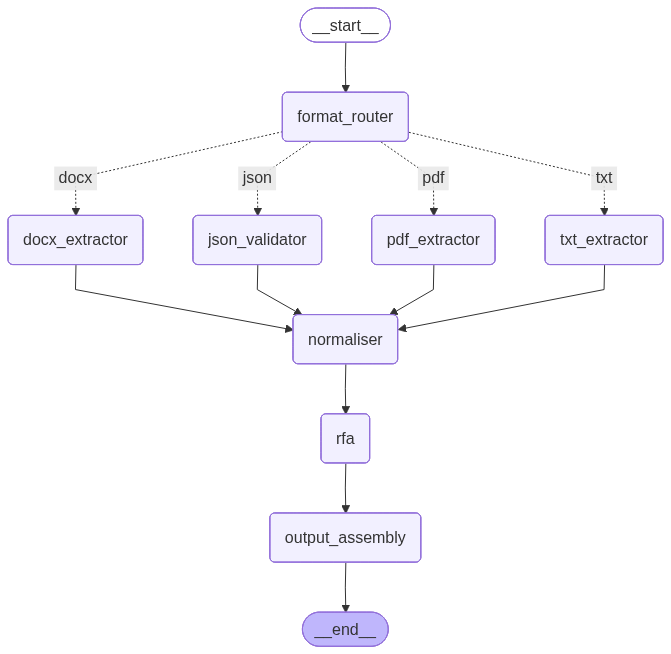

In [13]:
from IPython.display import Image, display

# 1. Compile the graph
graph = build_ingestion_graph()

# 2. Render and display the graph as a PNG image
# draw_mermaid_png() uses the Mermaid.ink API (no local packages required)
display(Image(graph.get_graph().draw_mermaid_png()))
